# LSTM Networks

Sentiment classification using Long Short Term Memory (LSTM) Networks

## Imports

In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt


print("imports done")

imports done


## Load Data

In [2]:
# for testing purposes
column_1 = 'review' # 'text' #name ng column for text
column_2 = 'sentiment' #name ng column for sentiment

train_df = pd.read_csv('data/train.csv').dropna(subset=[column_1])
val_df = pd.read_csv('data/val.csv').dropna(subset=[column_1])
print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")

Train size: 35000
Val size: 7500


## Preprocess The Text

It is important to preprocess the text info before sending it out to the model to make the process easier. This includes tokenizing the texts, encode the labels into integers, and sequencing it properly

In [ ]:
encoder = LabelEncoder()
tokenizer = Tokenizer(num_words=50000, oov_token='XXX') #get top 50,000 common words, oov means out of vocab -- make the token for oov XXX
num_class = 2 #always two since positive or negative only (must be changed if adding neutral)

tokenizer.fit_on_texts(train_df[column_1].astype(str).str.lower().str.strip().tolist())
encoder.fit(train_df[column_2].tolist())

with open('models/lstm_tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('models/lstm_encoder.pkl', 'wb') as handle:
    pickle.dump(encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved tokenizer and encoder to disk.")

def preprocess(dataframe):
    info = dataframe[column_1].astype(str).str.lower().str.strip().tolist()
    sentiment = dataframe[column_2].tolist()

    label = encoder.fit_transform(sentiment)

    sequences = tokenizer.texts_to_sequences(info) #convert to sequences
    pad = pad_sequences(sequences, maxlen=500, padding='post', truncating='post') #500 max number of sequence

    return label, pad

train_label, train_pad = preprocess(train_df)
val_label, val_pad = preprocess(val_df)

## Build LSTM Network

In [6]:
#try to get the smallest as possible
vocab_size = min(50000, len(tokenizer.word_index)+1)

model = Sequential([Embedding(input_dim=vocab_size,
                                output_dim=64,
                                input_length=500),
                    SpatialDropout1D(0.3),
                    Bidirectional(LSTM(64, #hidden units
                                       dropout=0.5,
                                       recurrent_dropout=0.2,
                                       return_sequences=False)),
                    Dense(32, activation='relu'),
                    Dropout(0.5),
                    Dense(num_class if num_class > 2 else 1,
                            activation="softmax" if num_class > 2 else "sigmoid")])

loss = ("sparse_categorical_crossentropy"
        if num_class > 2 else "binary_crossentropy")

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=5e-4),
    loss=loss,
    metrics=["accuracy"],
)

# model.summary() # empty for now since building palang

c:\Users\Judy Chua\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Train Model

In [7]:
callbacks = [EarlyStopping(patience=3,
                           restore_best_weights=True,
                           monitor="val_loss"),
             ModelCheckpoint("lstm_model.keras",
                             save_best_only=True,
                             monitor="val_loss"),
             ReduceLROnPlateau(monitor="val_loss",
                               factor=0.5, patience=2, # reduce learning rate by half if no improvement after 2 epoch
                               min_lr=1e-6, verbose=1)]

training = model.fit(train_pad, train_label,
                     validation_data=(val_pad, val_label),
                     epochs=10, batch_size=64,
                     callbacks=callbacks)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.6688 - loss: 0.5939 - val_accuracy: 0.7816 - val_loss: 0.4664 - learning_rate: 5.0000e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 567s 1s/step - accuracy: 0.8223 - loss: 0.4272 - val_accuracy: 0.8325 - val_loss: 0.3873 - learning_rate: 5.0000e-04
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 618s 1s/step - accuracy: 0.8640 - loss: 0.3550 - val_accuracy: 0.8443 - val_loss: 0.3621 - learning_rate: 5.0000e-04
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.8833 - loss: 0.3183 - val_accuracy: 0.8471 - val_loss: 0.3686 - learning_rate: 5.0000e-04
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.8976 - loss: 0.2801 - val_accuracy: 0.8539 - val_loss: 0.3592 - learning_rate: 5.0000e-04
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.9120 - loss: 0.2512 - val_accuracy: 0.8559 - val_loss: 0.3613 - learning_rate: 5.0000e-04
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - ac

Training curves saved → training_curves.png


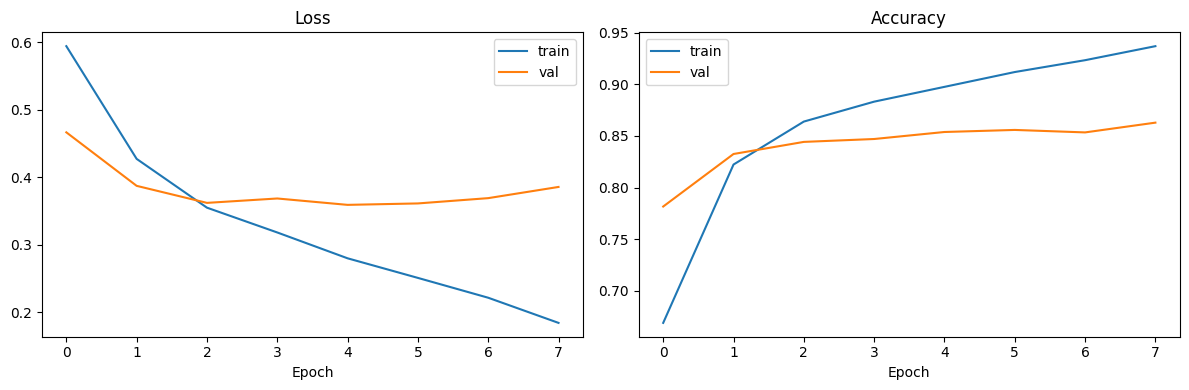

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(training.history[metric], label="train")
    ax.plot(training.history[f"val_{metric}"], label="val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
print("Training curves saved → training_curves.png")
plt.show()

## Evaluate on Testing Set

In [9]:
eval_df = pd.read_csv('data/test.csv').dropna(subset=[column_1])
print(f"Test size: {len(eval_df)}")

eval_label, eval_pad = preprocess(eval_df)

eval_loss, eval_acc = model.evaluate(eval_pad, eval_label, verbose=0)
print(f"Test loss is {eval_loss:.4f} while Test accuracy is {eval_acc:.4f}")

preds_raw = model.predict(eval_pad)
preds = (preds_raw.squeeze() >= 0.5).astype(int)

print(classification_report(eval_label, preds, target_names=[str(c) for c in encoder.classes_]))

Test size: 7500
Test loss is 0.3476 while Test accuracy is 0.8597
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step
              precision    recall  f1-score   support

    negative       0.86      0.86      0.86      3750
    positive       0.86      0.86      0.86      3750

    accuracy                           0.86      7500
   macro avg       0.86      0.86      0.86      7500
weighted avg       0.86      0.86      0.86      7500

